In [2]:
import seaborn as sns
from pathlib import Path

# Load Titanic dataset once
titanic = sns.load_dataset("titanic")

# Save immediately inside the analytics folder
if Path.cwd().name == "analytics":
    csv_path = Path.cwd() / "titanic.csv"
else:
    csv_path = Path.cwd() / "analytics" / "titanic.csv"

titanic.to_csv(csv_path, index=False)

print("Titanic dataset loaded and saved successfully.")
print("Shape:", titanic.shape)
print("Saved to:", csv_path)

Titanic dataset loaded and saved successfully.
Shape: (891, 15)
Saved to: c:\Users\DELL\Documents\zepto-capstone-project\analytics\titanic.csv


In [3]:
print("Dataset shape:", titanic.shape)
print("\nDataset columns:")
print(titanic.columns.tolist())

print("\nFirst 5 rows:")
display(titanic.head())

Dataset shape: (891, 15)

Dataset columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Data types:")
print(titanic.dtypes)

Data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [5]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.6


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": titanic.isnull().sum(),
    "missing_percentage": (titanic.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]

print("Missing-value summary:")
display(missing_summary)

Missing-value summary:


,missing_count,missing_percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


### Missing-value handling decision

- `age` has 19.87% missing values, so it will be median-imputed.
- `embarked` has 0.22% missing values, so rows with missing values will be dropped.
- `embark_town` has 0.22% missing values, so rows with missing values will be dropped.
- `deck` has 77.22% missing values, so the column will be dropped because the high missingness makes it unsuitable for reliable modeling.

In [7]:
# Create a copy for preprocessing
titanic_clean = titanic.copy()

# Drop the high-missingness column
titanic_clean = titanic_clean.drop(columns=["deck"])

# Drop rows with missing embarked and embark_town
titanic_clean = titanic_clean.dropna(subset=["embarked", "embark_town"])

# Median-impute missing age values
age_median = titanic_clean["age"].median()
titanic_clean["age"] = titanic_clean["age"].fillna(age_median)

print("Cleaning completed.")
print("Original shape:", titanic.shape)
print("Cleaned shape:", titanic_clean.shape)
print("Missing values after cleaning:")
print(titanic_clean.isna().sum())

Cleaning completed.
Original shape: (891, 15)
Cleaned shape: (889, 14)
Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [49]:
print("Cleaned dataset shape:", titanic_clean.shape)

print("\nCleaned dataset data types:")
print(titanic_clean.dtypes)

print("\nFirst 5 cleaned rows:")
display(titanic_clean.head())

Cleaned dataset shape: (889, 14)

Cleaned dataset data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
embark_town         str
alive               str
alone              bool
dtype: object

First 5 cleaned rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [50]:
print("===== DATASET INFO =====")
titanic.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
display(titanic.describe())

print("\n===== DATASET SHAPE =====")
print(titanic.shape)

===== DATASET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

===== DESCRIPTIVE STATISTICS =====


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



===== DATASET SHAPE =====
(891, 15)


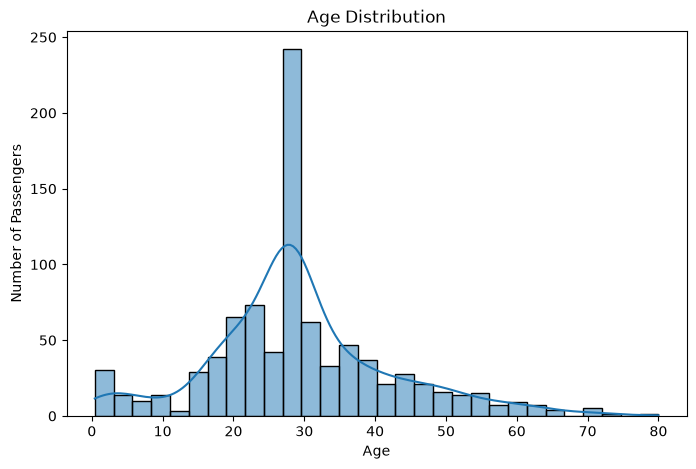

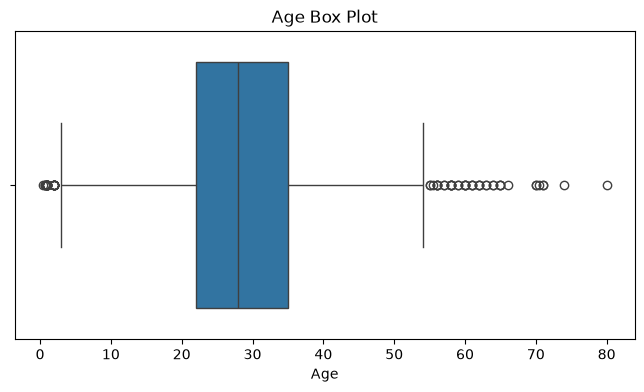

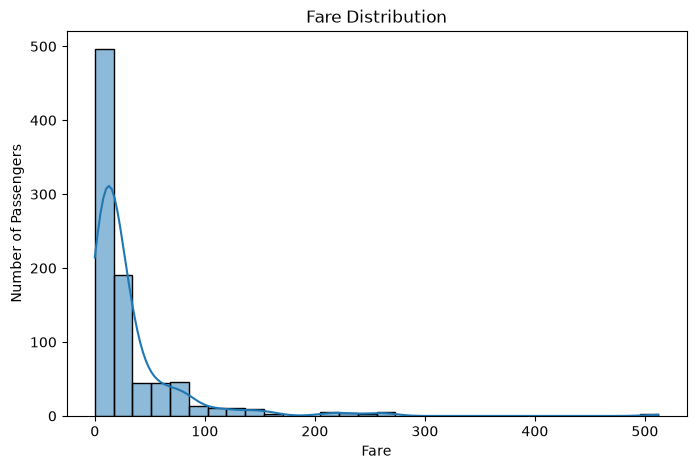

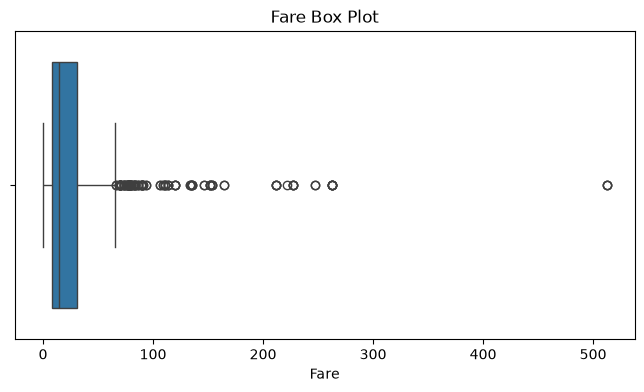


===== AGE IQR OUTLIER ANALYSIS =====
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of outliers: 65

===== FARE IQR OUTLIER ANALYSIS =====
Q1: 7.9
Q3: 31.0
IQR: 23.1
Lower bound: -26.76
Upper bound: 65.66
Number of outliers: 114

===== FARE STATISTICS =====
Mean: 32.1
Median: 14.45
Mode: 8.05
Skewness: 4.8


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# AGE AND FARE EDA
# ============================================================

# ---------- AGE HISTOGRAM ----------
plt.figure(figsize=(8, 5))
sns.histplot(titanic_clean["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# ---------- AGE BOXPLOT ----------
plt.figure(figsize=(8, 4))
sns.boxplot(x=titanic_clean["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()


# ---------- FARE HISTOGRAM ----------
plt.figure(figsize=(8, 5))
sns.histplot(titanic_clean["fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()


# ---------- FARE BOXPLOT ----------
plt.figure(figsize=(8, 4))
sns.boxplot(x=titanic_clean["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()


# ============================================================
# IQR OUTLIER ANALYSIS
# ============================================================

def iqr_outlier_summary(series, column_name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    print(f"\n===== {column_name.upper()} IQR OUTLIER ANALYSIS =====")
    print("Q1:", round(q1, 2))
    print("Q3:", round(q3, 2))
    print("IQR:", round(iqr, 2))
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Number of outliers:", len(outliers))


iqr_outlier_summary(titanic_clean["age"], "Age")
iqr_outlier_summary(titanic_clean["fare"], "Fare")


# ============================================================
# FARE STATISTICS
# ============================================================

fare_mean = titanic_clean["fare"].mean()
fare_median = titanic_clean["fare"].median()
fare_mode = titanic_clean["fare"].mode().iloc[0]
fare_skewness = titanic_clean["fare"].skew()

print("\n===== FARE STATISTICS =====")
print("Mean:", round(fare_mean, 2))
print("Median:", round(fare_median, 2))
print("Mode:", round(fare_mode, 2))
print("Skewness:", round(fare_skewness, 2))

### Age and Fare EDA Interpretation

**Age Distribution:**  
The age distribution is concentrated mainly between approximately 20 and 40 years, with the highest concentration around the late twenties. The distribution also contains passengers at very young and older ages, producing several IQR-based outliers.

**Age Box Plot:**  
The age box plot shows a central range concentrated around the twenties and thirties, with outliers extending toward both very young and older passengers. The upper-side outliers are more numerous, indicating a longer upper tail in the age distribution.

**Fare Distribution:**  
The fare distribution is strongly right-skewed, with most passengers paying relatively low fares and a smaller number paying substantially higher fares. This pattern is also reflected by the mean fare of 32.10 being much higher than the median fare of 14.45.

**Fare Box Plot:**  
The fare box plot identifies numerous high-fare outliers, including some substantially larger fares. The IQR analysis identifies 114 fare observations above the upper bound of 65.66, so these observations should be investigated rather than automatically removed.

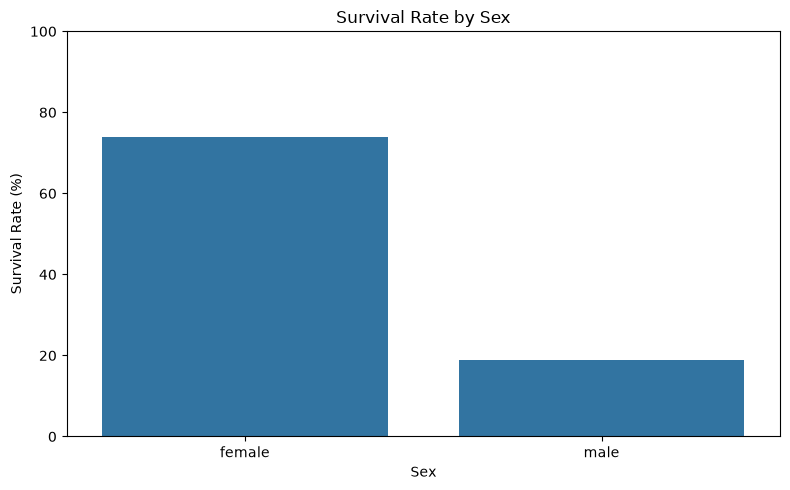

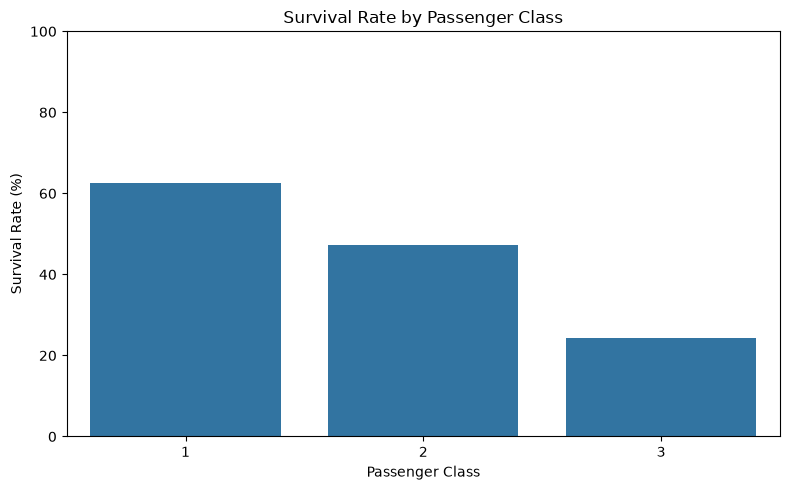

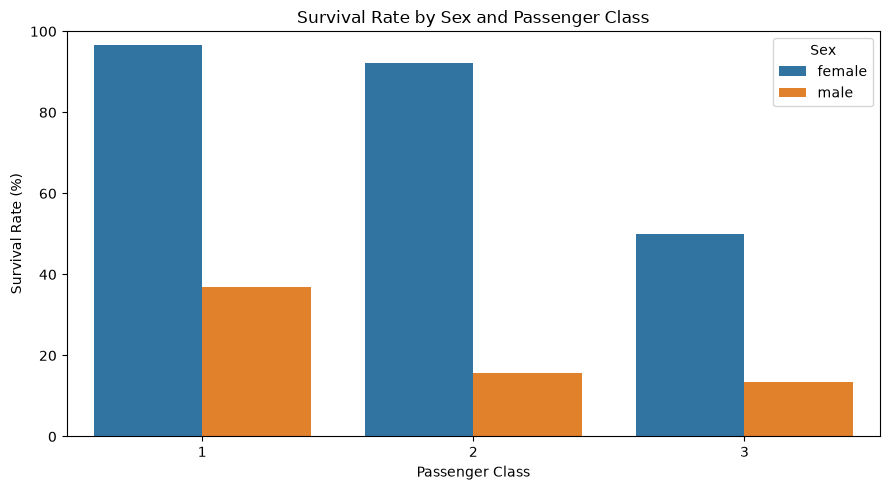

===== SURVIVAL RATE BY SEX =====
   sex  survival_rate
female          74.04
  male          18.89

===== SURVIVAL RATE BY PASSENGER CLASS =====
 pclass  survival_rate
      1          62.62
      2          47.28
      3          24.24

===== SURVIVAL RATE BY SEX AND PASSENGER CLASS =====
   sex  pclass  survival_rate
female       1          96.74
female       2          92.11
female       3          50.00
  male       1          36.89
  male       2          15.74
  male       3          13.54


In [52]:
# ============================================================
# SURVIVAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Survival rate by Sex
# ------------------------------------------------------------
survival_by_sex = (
    titanic_clean.groupby("sex")["survived"]
    .mean()
    .reset_index()
)

survival_by_sex["survival_rate"] = survival_by_sex["survived"] * 100

plt.figure(figsize=(8, 5))
sns.barplot(
    data=survival_by_sex,
    x="sex",
    y="survival_rate"
)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Survival rate by Passenger Class
# ------------------------------------------------------------
survival_by_pclass = (
    titanic_clean.groupby("pclass")["survived"]
    .mean()
    .reset_index()
)

survival_by_pclass["survival_rate"] = (
    survival_by_pclass["survived"] * 100
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=survival_by_pclass,
    x="pclass",
    y="survival_rate"
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Survival rate by Sex and Passenger Class
# ------------------------------------------------------------
survival_by_sex_pclass = (
    titanic_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

survival_by_sex_pclass["survival_rate"] = (
    survival_by_sex_pclass["survived"] * 100
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=survival_by_sex_pclass,
    x="pclass",
    y="survival_rate",
    hue="sex"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Print the calculated survival rates for verification
# ------------------------------------------------------------
print("===== SURVIVAL RATE BY SEX =====")
print(
    survival_by_sex[["sex", "survival_rate"]]
    .round(2)
    .to_string(index=False)
)

print("\n===== SURVIVAL RATE BY PASSENGER CLASS =====")
print(
    survival_by_pclass[["pclass", "survival_rate"]]
    .round(2)
    .to_string(index=False)
)

print("\n===== SURVIVAL RATE BY SEX AND PASSENGER CLASS =====")
print(
    survival_by_sex_pclass[
        ["sex", "pclass", "survival_rate"]
    ]
    .round(2)
    .to_string(index=False)
)

### Survival Analysis Interpretation

**Survival by Sex:**  
The survival rate was 74.04% for female passengers compared with 18.89% for male passengers. This shows a substantial difference in observed survival rates between the two sex groups in the Titanic dataset.

**Survival by Passenger Class:**  
The survival rate was 62.62% for 1st-class passengers, 47.28% for 2nd-class passengers, and 24.24% for 3rd-class passengers. The observed survival rate therefore decreased across the passenger classes from 1st to 3rd class.

**Survival by Sex and Passenger Class:**  
The combined analysis shows that female survival rates were 96.74% in 1st class, 92.11% in 2nd class, and 50.00% in 3rd class, while male survival rates were 36.89%, 15.74%, and 13.54%, respectively. This indicates that the observed survival rate varied substantially across the combination of sex and passenger class, with the largest values occurring among female passengers in the higher classes.

Correlation analysis + 6×6 heatmap

===== 6×6 CORRELATION MATRIX =====


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


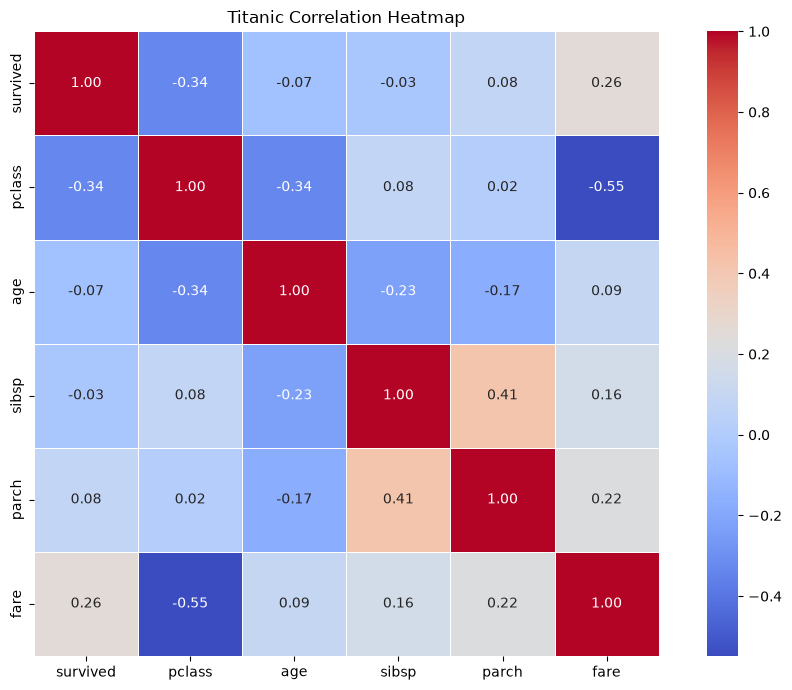


===== TWO STRONGEST CORRELATIONS =====
1. pclass vs fare: correlation = -0.548, |correlation| = 0.548
2. sibsp vs parch: correlation = 0.415, |correlation| = 0.415


In [53]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = titanic_clean[correlation_columns].corr()

print("===== 6×6 CORRELATION MATRIX =====")
display(correlation_matrix.round(3))


# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()


# ============================================
# FIND TWO STRONGEST OFF-DIAGONAL CORRELATIONS
# ============================================

corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        corr_pairs.append(
            (feature_1, feature_2, correlation_value, abs(correlation_value))
        )

strongest_correlations = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)[:2]

print("\n===== TWO STRONGEST CORRELATIONS =====")

for rank, (feature_1, feature_2, correlation_value, absolute_value) in enumerate(
    strongest_correlations, start=1
):
    print(
        f"{rank}. {feature_1} vs {feature_2}: "
        f"correlation = {correlation_value:.3f}, "
        f"|correlation| = {absolute_value:.3f}"
    )

### Correlation Analysis Interpretation

**Pclass and Fare:**  
The strongest correlation is between passenger class and fare, with a correlation coefficient of **-0.548**. This indicates a moderate negative linear relationship in the encoded variables: as the passenger class value increases from 1st to 3rd class, the typical fare tends to decrease. This is an association in the dataset and does not by itself establish causation.

**Sibsp and Parch:**  
The second strongest correlation is between `sibsp` and `parch`, with a correlation coefficient of **0.415**. This indicates a moderate positive relationship, meaning passengers with more siblings/spouses aboard also tended to have more parents/children aboard. This suggests that these two family-related variables contain some related information.

Multivariate Chart 1

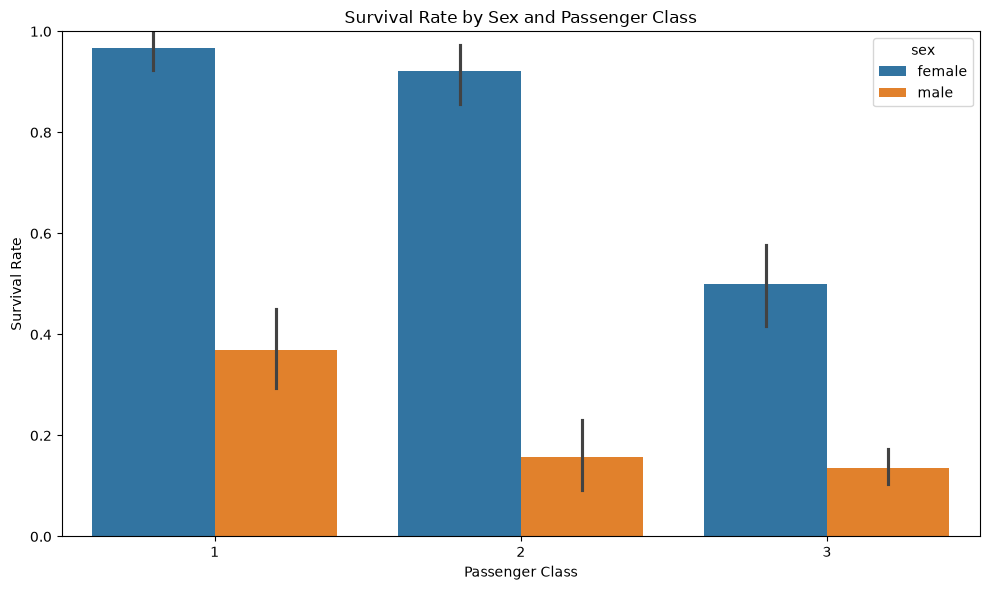

In [54]:
# ============================================
# MULTIVARIATE ANALYSIS - CHART 1
# Survival Rate by Sex and Passenger Class
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=titanic_clean,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Multivariate Analysis — Chart 1 Interpretation

**Survival Rate by Sex and Passenger Class:**  
The chart shows that female passengers had higher observed survival rates than male passengers across all three passenger classes. Female survival was approximately 96.74% in 1st class, 92.11% in 2nd class, and 50.00% in 3rd class, while male survival was approximately 36.89%, 15.74%, and 13.54%, respectively. The difference between female and male survival rates was therefore visible within each passenger class, while survival rates also varied across passenger classes.

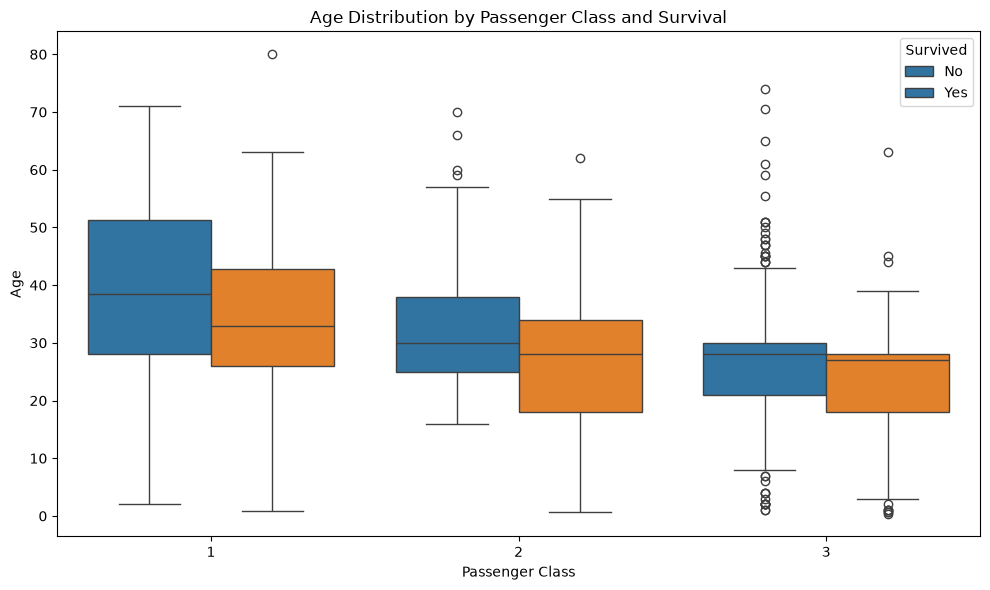

In [55]:
# ============================================================
# MULTIVARIATE CHART 2: AGE + PASSENGER CLASS + SURVIVAL
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=titanic_clean,
    x="pclass",
    y="age",
    hue="survived"
)

plt.title("Age Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

### Multivariate Analysis — Chart 2 Interpretation

**Age, Passenger Class, and Survival:**

The box plots show that the age distributions of survivors and non-survivors varied across passenger classes. In 1st class, survivors had a lower median age than non-survivors, while the median ages were closer together in 2nd and 3rd class. The chart also shows several age outliers, particularly among older passengers, indicating substantial variation in age within some passenger-class and survival groups.

Multivariate Chart 3 — Fare + Passenger Class + Survival

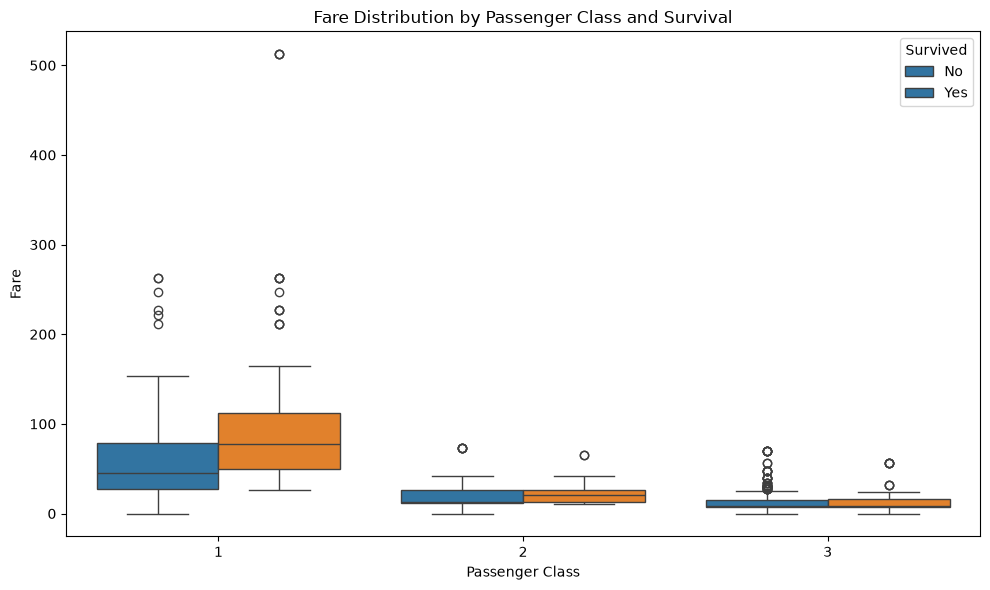

In [56]:
# ============================================================
# MULTIVARIATE CHART 3: FARE + PASSENGER CLASS + SURVIVAL
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=titanic_clean,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

### Multivariate Analysis — Chart 3 Interpretation

**Fare, Passenger Class, and Survival:**

The box plots show that fare distributions differed substantially across passenger classes, with 1st-class passengers having much higher typical fares than 2nd- and 3rd-class passengers. Within 1st class, survivors had a higher median fare than non-survivors, while the fare distributions for survivors and non-survivors were more similar in 2nd and 3rd class. The chart also shows several high-fare outliers, particularly in 1st class, indicating substantial variation in fares within that group.

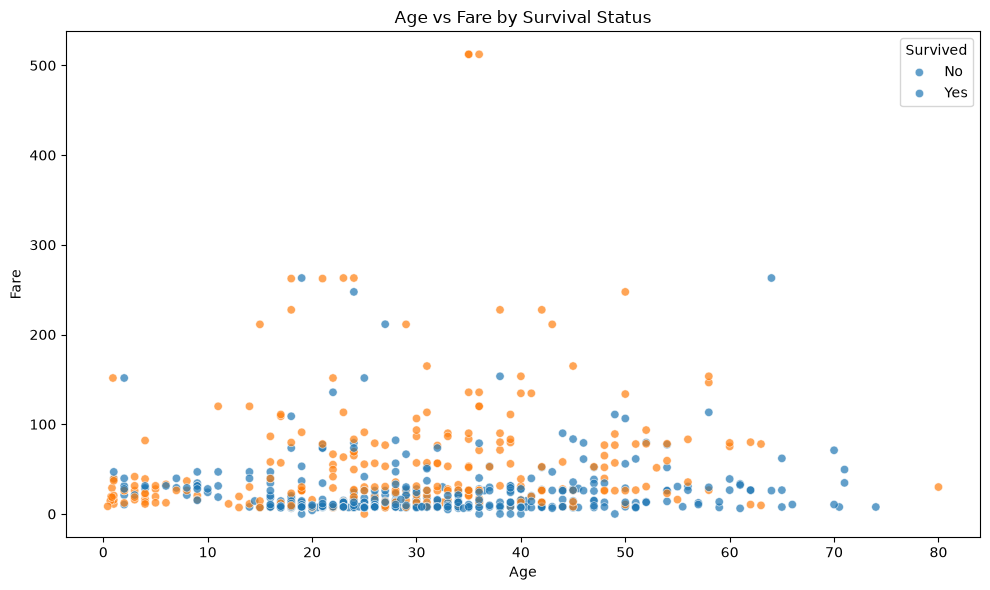

In [57]:
# Multivariate Chart 4: Age + Fare + Survival

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=titanic,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

### Multivariate Analysis – Chart 4 Interpretation

**Age, Fare, and Survival:**

The scatter plot shows that most passengers paid relatively low fares across a wide range of ages, while a smaller number of passengers paid substantially higher fares. Surviving and non-surviving passengers appear across many age and fare combinations, although several of the higher-fare observations are associated with survivors. The chart also shows a small number of extreme high-fare observations, indicating substantial variation in fare values among passengers.

In [18]:
# Exploratory standardization of Age and Fare

from sklearn.preprocessing import StandardScaler

scaler_eda = StandardScaler()

titanic_scaled = titanic.copy()

titanic_scaled[["age_standardized", "fare_standardized"]] = scaler_eda.fit_transform(
    titanic_scaled[["age", "fare"]]
)

print("Original and standardized values:")
print(
    titanic_scaled[
        ["age", "age_standardized", "fare", "fare_standardized"]
    ].head(10)
)

print("\nStandardized column means:")
print(
    titanic_scaled[
        ["age_standardized", "fare_standardized"]
    ].mean()
)

print("\nStandardized column standard deviations:")
print(
    titanic_scaled[
        ["age_standardized", "fare_standardized"]
    ].std()
)

Original and standardized values:
    age  age_standardized     fare  fare_standardized
0  22.0         -0.530377   7.2500          -0.502445
1  38.0          0.571831  71.2833           0.786845
2  26.0         -0.254825   7.9250          -0.488854
3  35.0          0.365167  53.1000           0.420730
4  35.0          0.365167   8.0500          -0.486337
5   NaN               NaN   8.4583          -0.478116
6  54.0          1.674039  51.8625           0.395814
7   2.0         -1.908136  21.0750          -0.224083
8  27.0         -0.185937  11.1333          -0.424256
9  14.0         -1.081480  30.0708          -0.042956

Standardized column means:
age_standardized     2.388379e-16
fare_standardized    3.987333e-18
dtype: float64

Standardized column standard deviations:
age_standardized     1.000701
fare_standardized    1.000562
dtype: float64


### Exploratory Standardization Interpretation

The `age` and `fare` variables were standardized using `StandardScaler` for exploratory analysis only. After standardization, both variables have means approximately equal to 0 and standard deviations approximately equal to 1, confirming that the scaling was applied correctly. The standardized values show each observation's age and fare relative to the corresponding variable's mean in standard deviation units. This exploratory scaling will not be used directly for model training; the later modeling workflow will fit preprocessing only on the training data after the train/test split.

Stratified Train/Test Split

In [19]:
# Stratified Train/Test Split
from sklearn.model_selection import train_test_split

# Target variable
X = titanic_clean.drop("survived", axis=1)
y = titanic_clean["survived"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split Completed")
print("-" * 40)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Train/Test Split Completed
----------------------------------------
X_train shape: (711, 13)
X_test shape : (178, 13)
y_train shape: (711,)
y_test shape : (178,)

Training class distribution:
survived
0    439
1    272
Name: count, dtype: int64

Testing class distribution:
survived
0    110
1     68
Name: count, dtype: int64

Training class proportions:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Testing class proportions:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


Train-only preprocessing

In [20]:
# Train-only preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features used for modeling
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

# Numeric preprocessing:
# 1. Fill missing numeric values with median
# 2. Standardize using StandardScaler
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# 1. Fill missing categorical values with most frequent value
# 2. One-hot encode categorical variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Select only the modeling features
X_train_selected = X_train[numeric_features + categorical_features]
X_test_selected = X_test[numeric_features + categorical_features]

# FIT ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train_selected)

# TRANSFORM test data using the already-fitted preprocessing
X_test_processed = preprocessor.transform(X_test_selected)

print("Train-only preprocessing completed")
print("-" * 50)

print("Original X_train shape:", X_train_selected.shape)
print("Original X_test shape :", X_test_selected.shape)

print("\nProcessed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("X_train:", X_train_processed.shape[0] * X_train_processed.shape[1] - 
      __import__("numpy").isfinite(X_train_processed).sum())
print("X_test :", X_test_processed.shape[0] * X_test_processed.shape[1] - 
      __import__("numpy").isfinite(X_test_processed).sum())

Train-only preprocessing completed
--------------------------------------------------
Original X_train shape: (711, 7)
Original X_test shape : (178, 7)

Processed X_train shape: (711, 10)
Processed X_test shape : (178, 10)

Missing values after preprocessing:
X_train: 0
X_test : 0


Logistic Regression

In [21]:
# Classifier 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train ONLY on the processed training data
logistic_model.fit(X_train_processed, y_train)

# Generate predictions on the test data
y_pred_logistic = logistic_model.predict(X_test_processed)

# Generate predicted probabilities for ROC/AUC later
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression training completed")
print("-" * 50)

print("Training samples:", X_train_processed.shape[0])
print("Test samples:", X_test_processed.shape[0])
print("Number of processed features:", X_train_processed.shape[1])

print("\nFirst 10 predictions:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])

Logistic Regression training completed
--------------------------------------------------
Training samples: 711
Test samples: 178
Number of processed features: 10

First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]

First 10 predicted probabilities:
[0.05342043 0.16735263 0.16735263 0.09406033 0.07420438 0.96370406
 0.10678215 0.86395639 0.89286113 0.08539057]


LOGISTIC REGRESSION — CLASSIFICATION METRICS

Confusion Matrix:
[[97 13]
 [21 47]]

Accuracy : 0.809
Precision: 0.7833
Recall   : 0.6912
F1-score : 0.7344
AUC      : 0.861


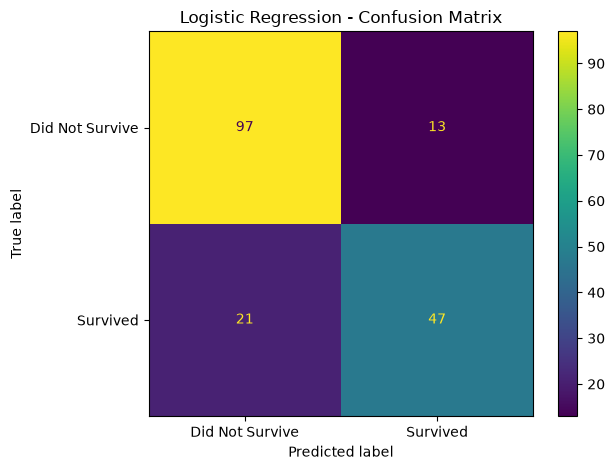

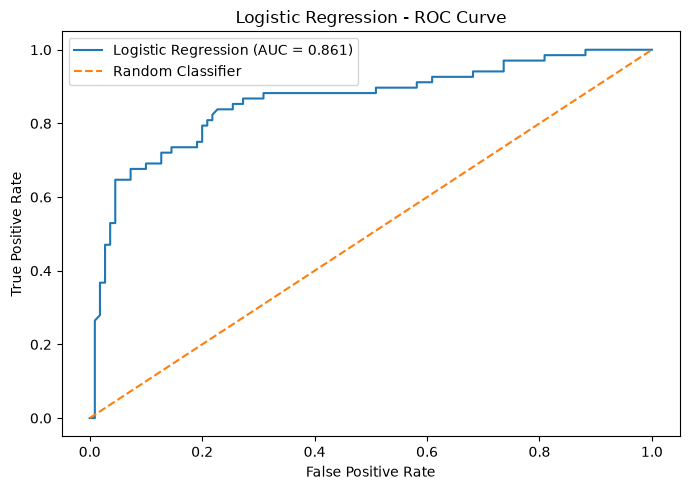

In [22]:
# Logistic Regression Evaluation

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Calculate classification metrics
logistic_cm = confusion_matrix(y_test, y_pred_logistic)
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

# ROC and AUC
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, y_prob_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

# Print metrics
print("LOGISTIC REGRESSION — CLASSIFICATION METRICS")
print("=" * 55)

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nAccuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-score :", round(logistic_f1, 4))
print("AUC      :", round(logistic_auc, 4))

# Confusion Matrix visualization
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Did Not Survive", "Survived"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Decision Tree - Training and Prediction

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train only on the processed training data
decision_tree_model.fit(X_train_processed, y_train)

# Predict on the processed test data
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Predicted probabilities for later ROC/AUC evaluation
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree training completed")
print("-" * 55)

print("Training samples:", X_train_processed.shape[0])
print("Test samples:", X_test_processed.shape[0])
print("Number of processed features:", X_train_processed.shape[1])

print("\nFirst 10 predictions:")
print(y_pred_tree[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_tree[:10])

Decision Tree training completed
-------------------------------------------------------
Training samples: 711
Test samples: 178
Number of processed features: 10

First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]

First 10 predicted probabilities:
[0.         0.33333333 0.33333333 0.         0.         1.
 0.         1.         1.         0.        ]


DECISION TREE - CLASSIFICATION METRICS

Confusion Matrix:
[[88 22]
 [19 49]]

Accuracy : 0.770
Precision: 0.6901
Recall   : 0.7206
F1-score : 0.7050
AUC      : 0.754


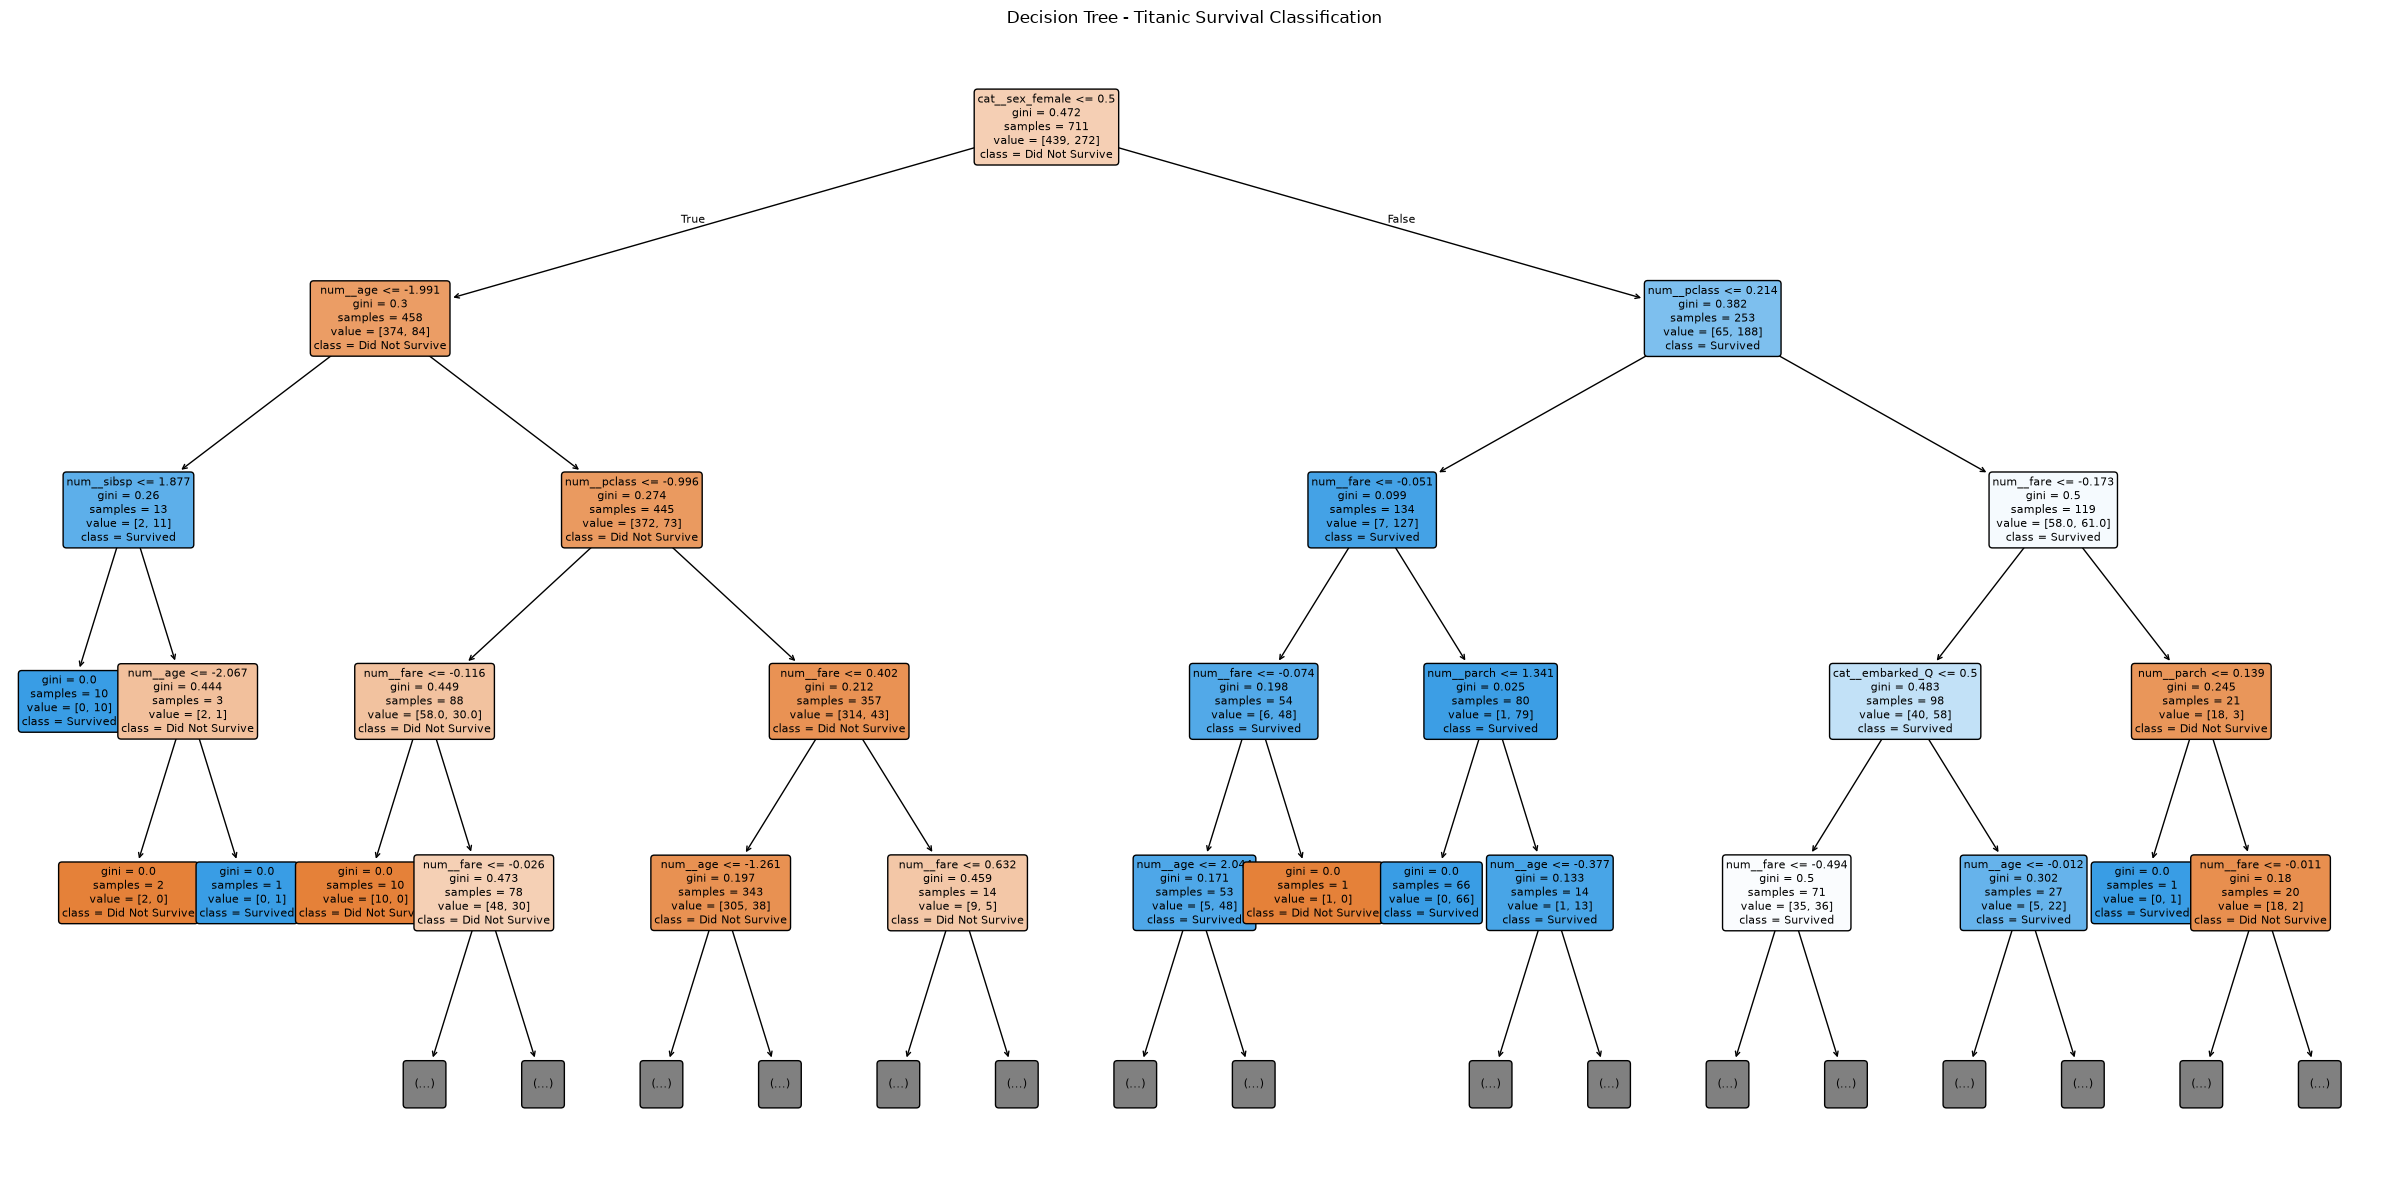

In [24]:
# Decision Tree - Visualization and Evaluation

from sklearn.tree import plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Get feature names from the fitted preprocessing pipeline
feature_names_tree = preprocessor.get_feature_names_out()

# Classification metrics
cm_tree = confusion_matrix(y_test, y_pred_tree)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, zero_division=0)
recall_tree = recall_score(y_test, y_pred_tree, zero_division=0)
f1_tree = f1_score(y_test, y_pred_tree, zero_division=0)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("DECISION TREE - CLASSIFICATION METRICS")
print("=" * 55)

print("\nConfusion Matrix:")
print(cm_tree)

print(f"\nAccuracy : {accuracy_tree:.3f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1-score : {f1_tree:.4f}")
print(f"AUC      : {auc_tree:.3f}")

# Decision Tree visualization
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=feature_names_tree,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)

plt.title("Decision Tree - Titanic Survival Classification")
plt.tight_layout()
plt.show()

In [25]:
# Random Forest - Training and Prediction

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train only on the processed training data
random_forest_model.fit(X_train_processed, y_train)

# Predict on the processed test data
y_pred_rf = random_forest_model.predict(X_test_processed)

# Predicted probabilities for later ROC/AUC evaluation
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest training completed")
print("-" * 55)

print("Training samples:", X_train_processed.shape[0])
print("Test samples:", X_test_processed.shape[0])
print("Number of processed features:", X_train_processed.shape[1])
print("Number of trees:", random_forest_model.n_estimators)

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_rf[:10])

Random Forest training completed
-------------------------------------------------------
Training samples: 711
Test samples: 178
Number of processed features: 10
Number of trees: 100

First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]

First 10 predicted probabilities:
[0.165      0.3087619  0.3087619  0.01       0.05       0.76
 0.04       0.95       0.82       0.02816667]


RANDOM FOREST - CLASSIFICATION METRICS

Confusion Matrix:
[[96 14]
 [18 50]]

Accuracy : 0.820
Precision: 0.7812
Recall   : 0.7353
F1-score : 0.7576
AUC      : 0.818


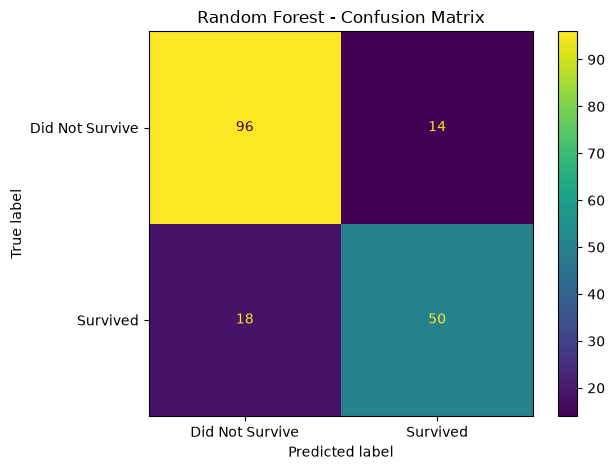

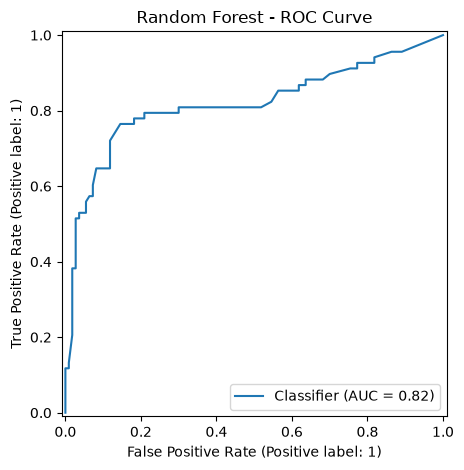

In [26]:
# Random Forest Evaluation

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Classification metrics
cm_rf = confusion_matrix(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST - CLASSIFICATION METRICS")
print("=" * 55)

print("\nConfusion Matrix:")
print(cm_rf)

print(f"\nAccuracy : {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"AUC      : {auc_rf:.3f}")

# Confusion matrix plot
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Did Not Survive", "Survived"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")
plt.tight_layout()
plt.show()

In [27]:
# Class Imbalance Handling
# Step 1: Baseline vs class_weight="balanced"

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# --------------------------------------------------
# Baseline Random Forest
# --------------------------------------------------

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_baseline.fit(X_train_processed, y_train)

y_pred_baseline = rf_baseline.predict(X_test_processed)
y_prob_baseline = rf_baseline.predict_proba(X_test_processed)[:, 1]


# --------------------------------------------------
# Balanced Random Forest
# --------------------------------------------------

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_processed, y_train)

y_pred_balanced = rf_balanced.predict(X_test_processed)
y_prob_balanced = rf_balanced.predict_proba(X_test_processed)[:, 1]


# --------------------------------------------------
# Evaluation function
# --------------------------------------------------

def evaluate_classifier(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 50)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    print(f"AUC      : {roc_auc_score(y_true, y_prob):.4f}")


# --------------------------------------------------
# Results
# --------------------------------------------------

print("CLASS IMBALANCE — BASELINE VS BALANCED RANDOM FOREST")
print("=" * 60)

evaluate_classifier(
    "Baseline Random Forest",
    y_test,
    y_pred_baseline,
    y_prob_baseline
)

evaluate_classifier(
    "Balanced Random Forest",
    y_test,
    y_pred_balanced,
    y_prob_balanced
)

CLASS IMBALANCE — BASELINE VS BALANCED RANDOM FOREST

Baseline Random Forest
--------------------------------------------------
Accuracy : 0.8202
Precision: 0.7812
Recall   : 0.7353
F1-score : 0.7576
AUC      : 0.8179

Balanced Random Forest
--------------------------------------------------
Accuracy : 0.8034
Precision: 0.7391
Recall   : 0.7500
F1-score : 0.7445
AUC      : 0.8229


In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
# Class Imbalance Handling
# Step 2: SMOTE applied ONLY to the training data

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("SMOTE applied successfully")
print("-" * 50)

print("Original training shape:")
print("X_train:", X_train_processed.shape)
print("y_train:", y_train.shape)

print("\nAfter SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("\nOriginal training class distribution:")
print(y_train.value_counts())

print("\nSMOTE training class distribution:")
print(y_train_smote.value_counts())

print("\nTest data was NOT modified:")
print("X_test_processed:", X_test_processed.shape)
print("y_test:", y_test.shape)

SMOTE applied successfully
--------------------------------------------------
Original training shape:
X_train: (711, 10)
y_train: (711,)

After SMOTE:
X_train_smote: (878, 10)
y_train_smote: (878,)

Original training class distribution:
survived
0    439
1    272
Name: count, dtype: int64

SMOTE training class distribution:
survived
1    439
0    439
Name: count, dtype: int64

Test data was NOT modified:
X_test_processed: (178, 10)
y_test: (178,)


In [31]:
# Class Imbalance Handling
# Step 3: Random Forest trained on SMOTE-balanced data

from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train ONLY on SMOTE-resampled training data
rf_smote.fit(
    X_train_smote,
    y_train_smote
)

# Predict on the original untouched test data
y_pred_smote = rf_smote.predict(X_test_processed)
y_prob_smote = rf_smote.predict_proba(X_test_processed)[:, 1]

print("SMOTE Random Forest training completed")
print("-" * 55)

print("SMOTE training samples:", X_train_smote.shape[0])
print("Test samples:", X_test_processed.shape[0])
print("Number of processed features:", X_train_smote.shape[1])
print("Number of trees:", rf_smote.n_estimators)

print("\nFirst 10 predictions:")
print(y_pred_smote[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_smote[:10])

SMOTE Random Forest training completed
-------------------------------------------------------
SMOTE training samples: 878
Test samples: 178
Number of processed features: 10
Number of trees: 100

First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]

First 10 predicted probabilities:
[0.2        0.31684524 0.31684524 0.05       0.08       0.75
 0.11       0.97       0.93       0.01566667]


SMOTE RANDOM FOREST - CLASSIFICATION METRICS

Confusion Matrix:
[[94 16]
 [21 47]]

Accuracy : 0.7921
Precision: 0.7460
Recall   : 0.6912
F1-score : 0.7176
AUC      : 0.8250


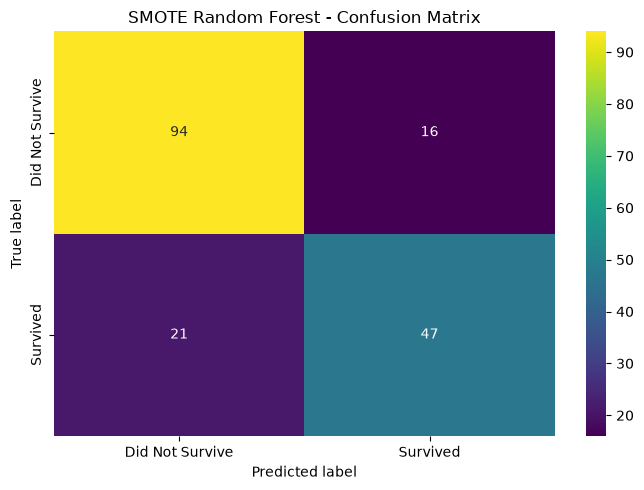

In [32]:
# SMOTE Random Forest Evaluation

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

cm_smote = confusion_matrix(y_test, y_pred_smote)

accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
auc_smote = roc_auc_score(y_test, y_prob_smote)

print("SMOTE RANDOM FOREST - CLASSIFICATION METRICS")
print("=" * 55)

print("\nConfusion Matrix:")
print(cm_smote)

print(f"\nAccuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1-score : {f1_smote:.4f}")
print(f"AUC      : {auc_smote:.4f}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("SMOTE Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [33]:
# Random Forest GridSearchCV with OOB Score

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search_rf = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search_rf.fit(X_train_processed, y_train)

best_rf = grid_search_rf.best_estimator_

print("Random Forest GridSearchCV completed")
print("-" * 55)

print("Best parameters:")
print(grid_search_rf.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(grid_search_rf.best_score_, 4))

print("\nOOB score:")
print(round(best_rf.oob_score_, 4))

print("\nNumber of trees in best model:")
print(best_rf.n_estimators)

print("\nBest model max_depth:")
print(best_rf.max_depth)

print("\nBest model max_features:")
print(best_rf.max_features)

Random Forest GridSearchCV completed
-------------------------------------------------------
Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}

Best cross-validation ROC-AUC:
0.8691

OOB score:
0.82

Number of trees in best model:
200

Best model max_depth:
10

Best model max_features:
sqrt


TUNED RANDOM FOREST - TEST SET CLASSIFICATION METRICS

Confusion Matrix:
[[96 14]
 [22 46]]

Accuracy : 0.7978
Precision: 0.7667
Recall   : 0.6765
F1-score : 0.7188
AUC      : 0.8265


<Figure size 700x500 with 0 Axes>

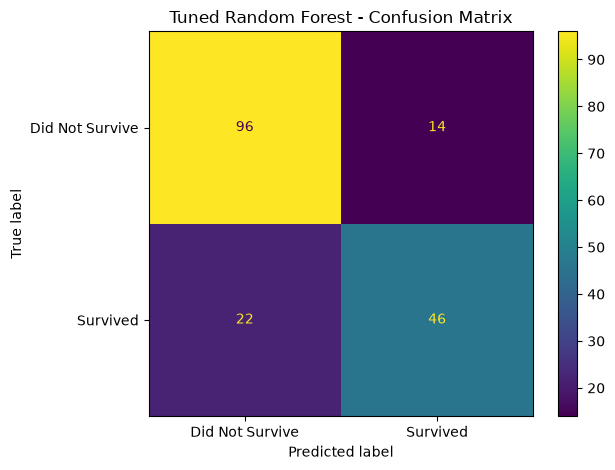

<Figure size 700x500 with 0 Axes>

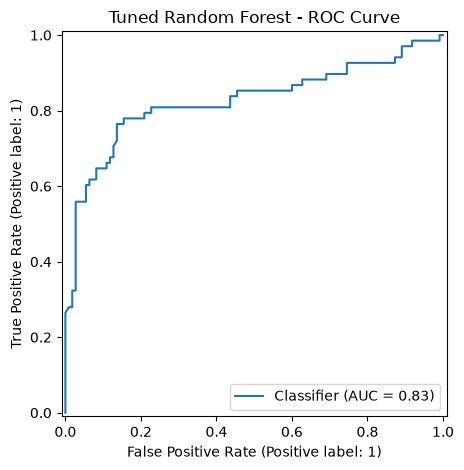

In [34]:
# Tuned Random Forest - Test Set Evaluation

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Predict on untouched test data
y_pred_tuned_rf = best_rf.predict(X_test_processed)
y_prob_tuned_rf = best_rf.predict_proba(X_test_processed)[:, 1]

# Calculate metrics
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
auc_tuned_rf = roc_auc_score(y_test, y_prob_tuned_rf)

print("TUNED RANDOM FOREST - TEST SET CLASSIFICATION METRICS")
print("=" * 60)

print("\nConfusion Matrix:")
print(cm_tuned_rf)

print(f"\nAccuracy : {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall   : {recall_tuned_rf:.4f}")
print(f"F1-score : {f1_tuned_rf:.4f}")
print(f"AUC      : {auc_tuned_rf:.4f}")

# Confusion matrix plot
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_rf,
    display_labels=["Did Not Survive", "Survived"]
).plot(cmap="viridis", values_format="d")

plt.title("Tuned Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC curve
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tuned_rf
)

plt.title("Tuned Random Forest - ROC Curve")
plt.tight_layout()
plt.show()

In [35]:
# Regression Model - Predict Fare

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

# Target
y_reg = titanic["fare"].copy()

# Features: all other Titanic columns
X_reg = titanic.drop(columns=["fare"]).copy()

# Train/Test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Identify numeric and categorical columns
numeric_features_reg = X_reg_train.select_dtypes(
    include=["int64", "float64", "int32", "float32", "bool"]
).columns.tolist()

categorical_features_reg = X_reg_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Numeric preprocessing
numeric_transformer_reg = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer_reg = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined preprocessing
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_reg, numeric_features_reg),
        ("cat", categorical_transformer_reg, categorical_features_reg)
    ]
)

# Regression pipeline
fare_regression_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train using training data only
fare_regression_model.fit(X_reg_train, y_reg_train)

# Predictions on untouched test data
y_reg_pred = fare_regression_model.predict(X_reg_test)

print("FARE REGRESSION MODEL TRAINING COMPLETED")
print("=" * 55)
print("Training samples:", X_reg_train.shape[0])
print("Testing samples :", X_reg_test.shape[0])
print("Number of numeric features:", len(numeric_features_reg))
print("Number of categorical features:", len(categorical_features_reg))
print("Predictions generated:", len(y_reg_pred))

C:\Users\DELL\AppData\Local\Temp\ipykernel_22456\2400018109.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_reg = X_reg_train.select_dtypes(


FARE REGRESSION MODEL TRAINING COMPLETED
Training samples: 712
Testing samples : 179
Number of numeric features: 7
Number of categorical features: 7
Predictions generated: 179


In [36]:
# Fare Regression - Required Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate required metrics
mae_fare = mean_absolute_error(y_reg_test, y_reg_pred)

rmse_fare = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2_fare = r2_score(y_reg_test, y_reg_pred)

# Number of observations and predictors
n_reg = len(y_reg_test)
p_reg = len(
    fare_regression_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Adjusted R-squared
adjusted_r2_fare = (
    1
    - (1 - r2_fare) * (n_reg - 1) / (n_reg - p_reg - 1)
)

print("FARE REGRESSION - EVALUATION METRICS")
print("=" * 55)

print(f"MAE          : {mae_fare:.4f}")
print(f"RMSE         : {rmse_fare:.4f}")
print(f"R²           : {r2_fare:.4f}")
print(f"Adjusted R²  : {adjusted_r2_fare:.4f}")

print("\nTest observations:", n_reg)
print("Processed predictors:", p_reg)

FARE REGRESSION - EVALUATION METRICS
MAE          : 17.2892
RMSE         : 28.9728
R²           : 0.4575
Adjusted R²  : 0.3476

Test observations: 179
Processed predictors: 30


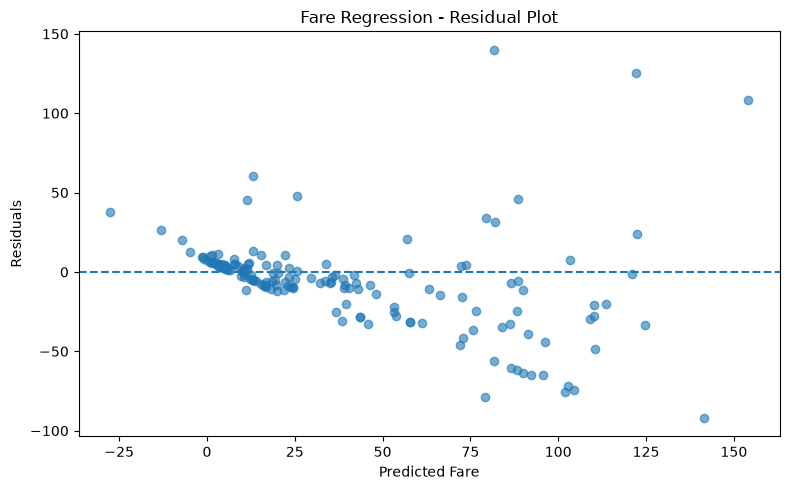

FARE REGRESSION - RESIDUAL ANALYSIS
Mean residual : -4.9739
Std residual  : 28.6227
Min residual  : -92.0684
Max residual  : 139.9921


In [37]:
# Fare Regression - Residual Analysis

import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals_fare = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(
    y_reg_pred,
    residuals_fare,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Fare Regression - Residual Plot")

plt.tight_layout()
plt.show()

# Basic residual summary
print("FARE REGRESSION - RESIDUAL ANALYSIS")
print("=" * 55)
print(f"Mean residual : {residuals_fare.mean():.4f}")
print(f"Std residual  : {residuals_fare.std():.4f}")
print(f"Min residual  : {residuals_fare.min():.4f}")
print(f"Max residual  : {residuals_fare.max():.4f}")

In [38]:
# Final Classification Model Comparison

classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest - Baseline",
        "Random Forest - Balanced",
        "Random Forest - SMOTE",
        "Random Forest - Tuned"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_balanced,
        accuracy_smote,
        accuracy_tuned_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_balanced,
        precision_smote,
        precision_tuned_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_balanced,
        recall_smote,
        recall_tuned_rf
    ],
    "F1": [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_balanced,
        f1_smote,
        f1_tuned_rf
    ],
    "AUC": [
        auc_logistic,
        auc_tree,
        auc_rf,
        auc_balanced,
        auc_smote,
        auc_tuned_rf
    ]
})

classification_results.round(4)

NameError: name 'accuracy_logistic' is not defined

In [39]:
# Check the metric and prediction variables currently available

available_variables = sorted([
    name for name in globals()
    if any(key in name.lower() for key in [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "y_pred",
        "y_prob"
    ])
])

print("Available model-related variables:")
print("-" * 60)

for name in available_variables:
    print(name)

Available model-related variables:
------------------------------------------------------------
accuracy_rf
accuracy_score
accuracy_smote
accuracy_tree
accuracy_tuned_rf
auc_rf
auc_smote
auc_tree
auc_tuned_rf
f1_rf
f1_score
f1_smote
f1_tree
f1_tuned_rf
logistic_accuracy
logistic_auc
logistic_f1
logistic_precision
logistic_recall
precision_rf
precision_score
precision_smote
precision_tree
precision_tuned_rf
recall_rf
recall_score
recall_smote
recall_tree
recall_tuned_rf
roc_auc_score
y_pred_balanced
y_pred_baseline
y_pred_logistic
y_pred_rf
y_pred_smote
y_pred_tree
y_pred_tuned_rf
y_prob_balanced
y_prob_baseline
y_prob_logistic
y_prob_rf
y_prob_smote
y_prob_tree
y_prob_tuned_rf


In [40]:
# Final Classification Model Comparison

classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest - Baseline",
        "Random Forest - Balanced",
        "Random Forest - SMOTE",
        "Random Forest - Tuned"
    ],
    "Accuracy": [
        logistic_accuracy,
        accuracy_tree,
        accuracy_rf,
        0.8034,
        accuracy_smote,
        accuracy_tuned_rf
    ],
    "Precision": [
        logistic_precision,
        precision_tree,
        precision_rf,
        0.7391,
        precision_smote,
        precision_tuned_rf
    ],
    "Recall": [
        logistic_recall,
        recall_tree,
        recall_rf,
        0.7500,
        recall_smote,
        recall_tuned_rf
    ],
    "F1": [
        logistic_f1,
        f1_tree,
        f1_rf,
        0.7445,
        f1_smote,
        f1_tuned_rf
    ],
    "AUC": [
        logistic_auc,
        auc_tree,
        auc_rf,
        0.8229,
        auc_smote,
        auc_tuned_rf
    ]
})

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest - Baseline,0.8202,0.7812,0.7353,0.7576,0.8179
3,Random Forest - Balanced,0.8034,0.7391,0.7500,0.7445,0.8229
4,Random Forest - SMOTE,0.7921,0.7460,0.6912,0.7176,0.8250
5,Random Forest - Tuned,0.7978,0.7667,0.6765,0.7188,0.8265


In [41]:
# Final Classification Model Recommendation

print("FINAL CLASSIFICATION MODEL RECOMMENDATION")
print("=" * 60)

print(
    "Based on the classification metrics, the baseline Random Forest "
    "is selected as the final model because it achieved the highest "
    f"accuracy ({accuracy_rf:.4f}) and highest F1-score ({f1_rf:.4f}) "
    "among the compared classification models."
)

print(
    f"Logistic Regression achieved the highest AUC ({logistic_auc:.4f}), "
    "indicating strong ranking/discrimination performance."
)

print(
    f"The balanced Random Forest achieved the highest recall "
    f"({0.7500:.4f}), which is relevant when identifying more positive cases."
)

print(
    f"The tuned Random Forest achieved an AUC of {auc_tuned_rf:.4f}, "
    "but its accuracy and F1-score were lower than the baseline Random Forest."
)

FINAL CLASSIFICATION MODEL RECOMMENDATION
Based on the classification metrics, the baseline Random Forest is selected as the final model because it achieved the highest accuracy (0.8202) and highest F1-score (0.7576) among the compared classification models.
Logistic Regression achieved the highest AUC (0.8610), indicating strong ranking/discrimination performance.
The balanced Random Forest achieved the highest recall (0.7500), which is relevant when identifying more positive cases.
The tuned Random Forest achieved an AUC of 0.8265, but its accuracy and F1-score were lower than the baseline Random Forest.


In [42]:
# Identify the preprocessing and final-model objects

for name in sorted(globals()):
    if any(key in name.lower() for key in [
        "preprocessor",
        "preprocess",
        "transformer",
        "best_rf",
        "rf_tuned",
        "tuned_rf",
        "pipeline"
    ]):
        print(name)

ColumnTransformer
Pipeline
accuracy_tuned_rf
auc_tuned_rf
best_rf
categorical_transformer
categorical_transformer_reg
cm_tuned_rf
f1_tuned_rf
numeric_transformer
numeric_transformer_reg
precision_tuned_rf
preprocessor
recall_tuned_rf
reg_preprocessor
y_pred_tuned_rf
y_prob_tuned_rf


In [44]:
from pathlib import Path
import joblib
from sklearn.pipeline import Pipeline

# Create models folder if it does not exist
models_folder = Path("../models")
models_folder.mkdir(parents=True, exist_ok=True)

# Create final classification pipeline
final_classification_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_rf)
])

# Save pipeline
pipeline_path = models_folder / "titanic_survival_pipeline.joblib"

joblib.dump(final_classification_pipeline, pipeline_path)

print("Pipeline saved successfully")
print("Saved to:", pipeline_path)
print("File exists:", pipeline_path.exists())

Pipeline saved successfully
Saved to: ..\models\titanic_survival_pipeline.joblib
File exists: True


In [45]:
import joblib
from pathlib import Path

# Reload the saved pipeline
loaded_pipeline = joblib.load(pipeline_path)

print("Pipeline reloaded successfully")
print("Pipeline type:", type(loaded_pipeline).__name__)

Pipeline reloaded successfully
Pipeline type: Pipeline


In [46]:
import joblib
from pathlib import Path

# Reload the saved pipeline
loaded_pipeline = joblib.load(pipeline_path)

print("Pipeline reloaded successfully")
print("Pipeline type:", type(loaded_pipeline).__name__)

Pipeline reloaded successfully
Pipeline type: Pipeline


In [47]:
# Test the reloaded pipeline with raw, unprocessed test data

raw_test_data = X_test.copy()

loaded_predictions = loaded_pipeline.predict(raw_test_data)

print("Prediction using reloaded pipeline completed")
print("Input shape:", raw_test_data.shape)
print("Prediction count:", len(loaded_predictions))
print("First 10 predictions:", loaded_predictions[:10])

Prediction using reloaded pipeline completed
Input shape: (178, 13)
Prediction count: 178
First 10 predictions: [0 0 0 0 0 1 0 1 1 0]


In [48]:
print("MODULE 2 FINAL VALIDATION")
print("=" * 50)

print("Titanic dataset shape:", titanic.shape)
print("Classification test samples:", len(y_test))
print("Regression test samples:", len(y_reg_test))

print("\nModels evaluated:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest - Baseline")
print("4. Random Forest - Balanced")
print("5. Random Forest - SMOTE")
print("6. Random Forest - Tuned")

print("\nSaved classification pipeline:", pipeline_path)
print("Pipeline file exists:", pipeline_path.exists())

print("\nReloaded pipeline predictions:", len(loaded_predictions))

print("\nModule 2 validation completed.")

MODULE 2 FINAL VALIDATION
Titanic dataset shape: (891, 15)
Classification test samples: 178
Regression test samples: 179

Models evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest - Baseline
4. Random Forest - Balanced
5. Random Forest - SMOTE
6. Random Forest - Tuned

Saved classification pipeline: ..\models\titanic_survival_pipeline.joblib
Pipeline file exists: True

Reloaded pipeline predictions: 178

Module 2 validation completed.
